<a href="https://colab.research.google.com/github/bruleonel/banco-de-dados/blob/main/analise_dados_fipe_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exportação da biblioteca PANDAS para manipulação de tabelas - Exercício 1;**

In [1]:
import pandas as pd

**Exportação das bibliotecas MATPLOTLIB e SEABORN para criação de gráficos - Exercício 2;**

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

**1-a. Carregando a base;**

In [73]:
df = pd.read_csv("fipe_2022.csv")

**1-b. Verificando valores faltantes;**


In [74]:
faltantes = df.isnull().sum().to_frame(name="Valores Faltantes")
faltantes

,Valores Faltantes
year_of_reference,0
month_of_reference,0
fipe_code,0
authentication,0
brand,0
model,0
fuel,0
gear,0
engine_size,0
year_model,0


**1.c Verificando dados duplicados;**

In [77]:
# ajustar largura das colunas para não cortar textos longos
pd.set_option('display.max_colwidth', None)

# identificar duplicados (mostra original + duplicado)
duplicados = df[df.duplicated(keep=False)]

# verificar quantidade
qtd_duplicados = df.duplicated().sum()

if qtd_duplicados > 0:
    print(f"Foram encontrados {qtd_duplicados} registros duplicados na base de dados.")
    print("Exibindo os registros duplicados para verificação:\n")

    display(
        duplicados
        .sort_values(by=['brand','model'])
        .style.set_properties(subset=['model'], **{'min-width': '400px'})
    )

else:
    print("OK: Não foram encontrados registros duplicados.")

Foram encontrados 2 registros duplicados na base de dados.
Exibindo os registros duplicados para verificação:



,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl,age_years
275481,2022,December,003296-4,3r6c277cnqcb,Ford,Ranger Limited 3.0 PSE 4x4 CD TB Diesel,Diesel,manual,3.000000,2007,64638.000000,16
275482,2022,December,003296-4,3r6c277cnqcb,Ford,Ranger Limited 3.0 PSE 4x4 CD TB Diesel,Diesel,manual,3.000000,2007,64638.000000,16
98996,2022,May,004051-7,gb76cyvp29j4,GM - Chevrolet,Monza Classic SE 2.0 /MPFI e EFI 2p e 4p,Gasoline,manual,2.000000,1992,10655.000000,31
99002,2022,May,004051-7,gb76cyvp29j4,GM - Chevrolet,Monza Classic SE 2.0 /MPFI e EFI 2p e 4p,Gasoline,manual,2.000000,1992,10655.000000,31


**1.d Separar variáveis numéricas e categóricas + estatística**

In [82]:
import pandas as pd

# remover variável que não faz sentido para estatística
df_corrigido = df.drop(columns=['year_of_reference'])

# separar variáveis
numericas = df_corrigido.select_dtypes(include=['int64','float64'])
categoricas = df_corrigido.select_dtypes(include=['object'])

# ---------- VARIÁVEIS NUMÉRICAS ----------

estat_num = numericas.describe().T

estat_num = estat_num.rename(columns={
    'mean':'Média',
    'std':'Desvio padrão',
    'min':'Mínimo',
    '25%':'25%',
    '50%':'Mediana',
    '75%':'75%',
    'max':'Máximo'
})

estat_num = estat_num[['Média','Desvio padrão','Mínimo','25%','Mediana','75%','Máximo']]

print("Estatísticas das Variáveis Numéricas")
display(
    estat_num.style.set_properties(**{'border-bottom':'1px solid #eee'})
)

# ---------- VARIÁVEIS CATEGÓRICAS ----------

estat_cat = categoricas.describe().T

estat_cat = estat_cat.rename(columns={
    'unique':'Quantidade de categorias',
    'top':'Valor mais frequente',
    'freq':'Frequência'
})

estat_cat = estat_cat[['Quantidade de categorias','Valor mais frequente','Frequência']]

print("Estatísticas das Variáveis Categóricas")
display(
    estat_cat.style.set_properties(**{'border-bottom':'1px solid #eee'})
)

# informação separada do ano
print("Ano de referência da base de dados:", df['year_of_reference'].unique())

Estatísticas das Variáveis Numéricas


,Média,Desvio padrão,Mínimo,25%,Mediana,75%,Máximo
engine_size,2.266047,1.033109,0.700000,1.600000,2.000000,2.800000,6.700000
year_model,2008.896633,9.263619,1985.000000,2001.000000,2010.000000,2016.000000,2023.000000
avg_price_brl,122087.206184,321913.886198,1831.000000,21875.000000,46836.000000,106165.000000,8600000.000000
age_years,14.103367,9.263619,0.000000,7.000000,13.000000,22.000000,38.000000


Estatísticas das Variáveis Categóricas


,Quantidade de categorias,Valor mais frequente,Frequência
month_of_reference,12,November,24366
fipe_code,5903,039001-1,443
authentication,290273,3r6c277cnqcb,2
brand,86,GM - Chevrolet,28179
model,6064,Buggy/M-8/M-8 Long 1.6,443
fuel,3,Gasoline,238774
gear,2,manual,210291


Ano de referência da base de dados: [2022]


**1.e Contagem por modelo e marca**

In [84]:
df['brand'].value_counts()

,count
brand,
GM - Chevrolet,28179
VW - VolksWagen,28142
Fiat,26563
Ford,24150
Mercedes-Benz,17470
...,...
GEELY,24
Lotus,24
SHINERAY,24


In [83]:
df['model'].value_counts()

,count
model,
Buggy/M-8/M-8 Long 1.6,443
Buggy Plus 1.6 8V,423
Buggy 1.6/ TST/ RS 1.6 4-Lug.,386
911 Turbo Coupe 3.6/3.8 (991/992),292
Forester 2.0/2.0 S/2.0 ES 4x4 Aut.,282
...,...
DAILY 45-170 FURGÃO 3.0 12m³ (Die)(E5),2
DAILY CHASSI 60-170 3.0 (Diesel)(E5),2
Corolla Cross SE 1.8 16V Aut. (Hybrid),1


**2.a Gráfico quantidade de carros por marca**

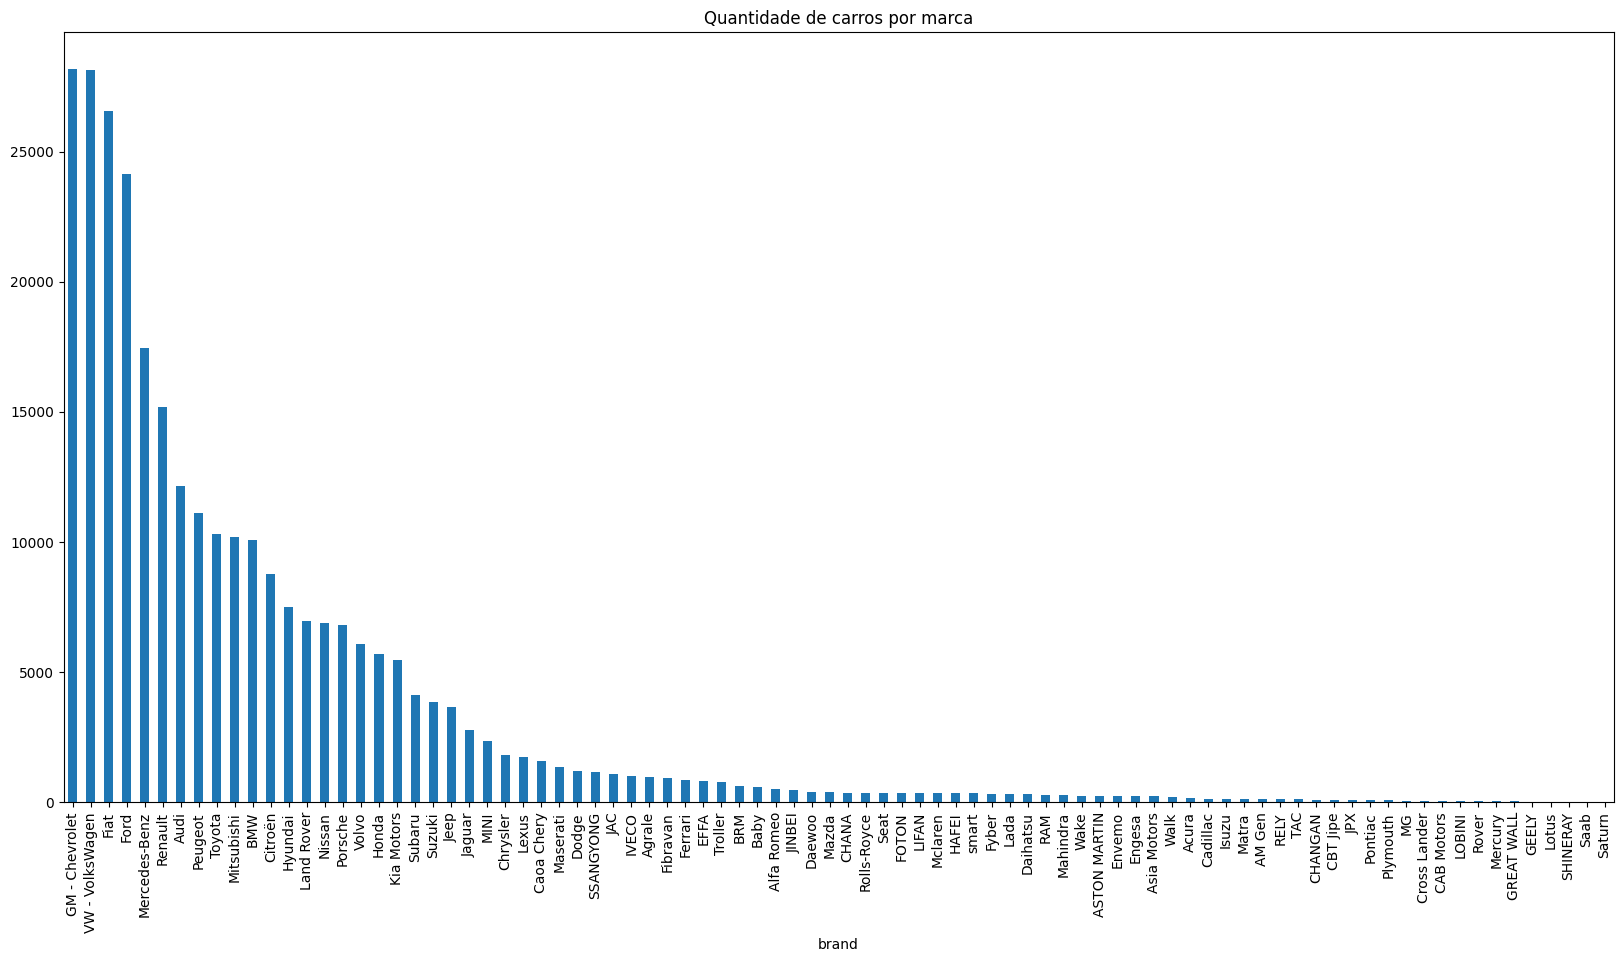

In [85]:
plt.figure(figsize=(20,10))
df['brand'].value_counts().plot(kind='bar')
plt.title("Quantidade de carros por marca")
plt.show()

**2.b Gráfico quantidade por engrenagem**

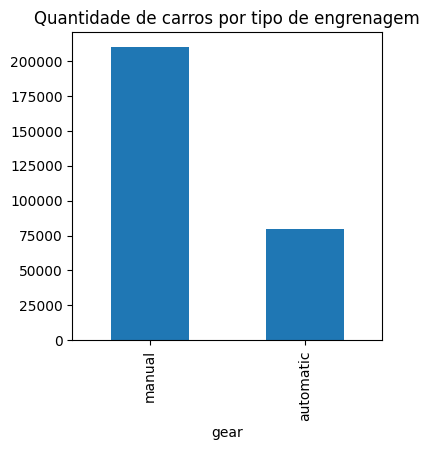

In [64]:
plt.figure(figsize=(4,4))
df['gear'].value_counts().plot(kind='bar')
plt.title("Quantidade de carros por tipo de engrenagem")
plt.show()

**2.c Evolução da média de preço ao longo dos meses**

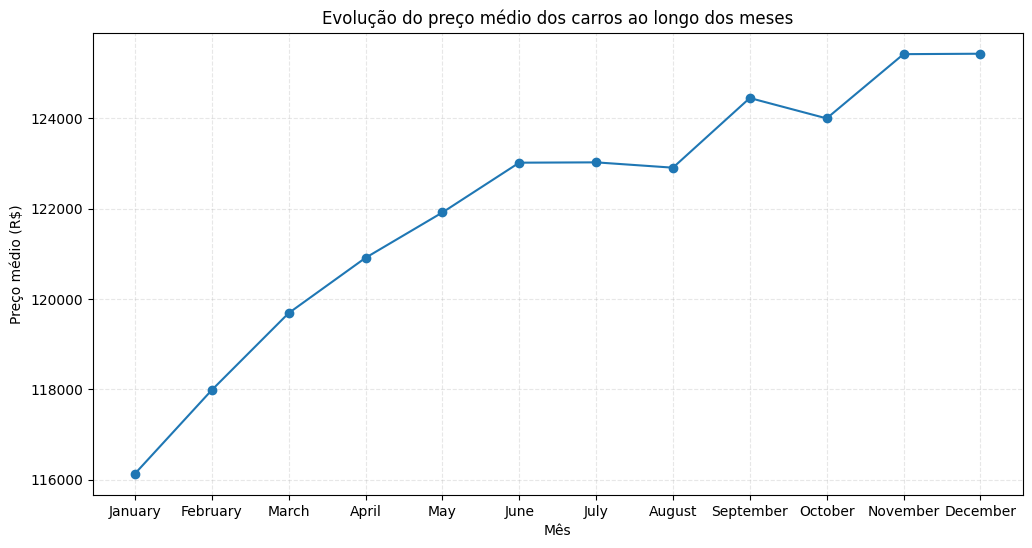

In [66]:
plt.figure(figsize=(12,6))

# limpar possíveis espaços ou problemas no texto
df['month_of_reference'] = df['month_of_reference'].astype(str).str.strip()

# calcular média por mês
media_mes = df.groupby('month_of_reference')['avg_price_brl'].mean()

# ordem correta dos meses
ordem = [
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

# manter apenas os meses que existem no dataset
media_mes = media_mes.loc[media_mes.index.intersection(ordem)]

# ordenar pelos meses
media_mes = media_mes.reindex(ordem)

# remover meses vazios
media_mes = media_mes.dropna()

# gráfico
plt.plot(media_mes.index, media_mes.values, marker='o')

plt.title("Evolução do preço médio dos carros ao longo dos meses")
plt.xlabel("Mês")
plt.ylabel("Preço médio (R$)")

plt.grid(True, linestyle='--', alpha=0.3)

plt.ticklabel_format(style='plain', axis='y')

plt.show()

**2.d Preço médio por marca e engrenagem**

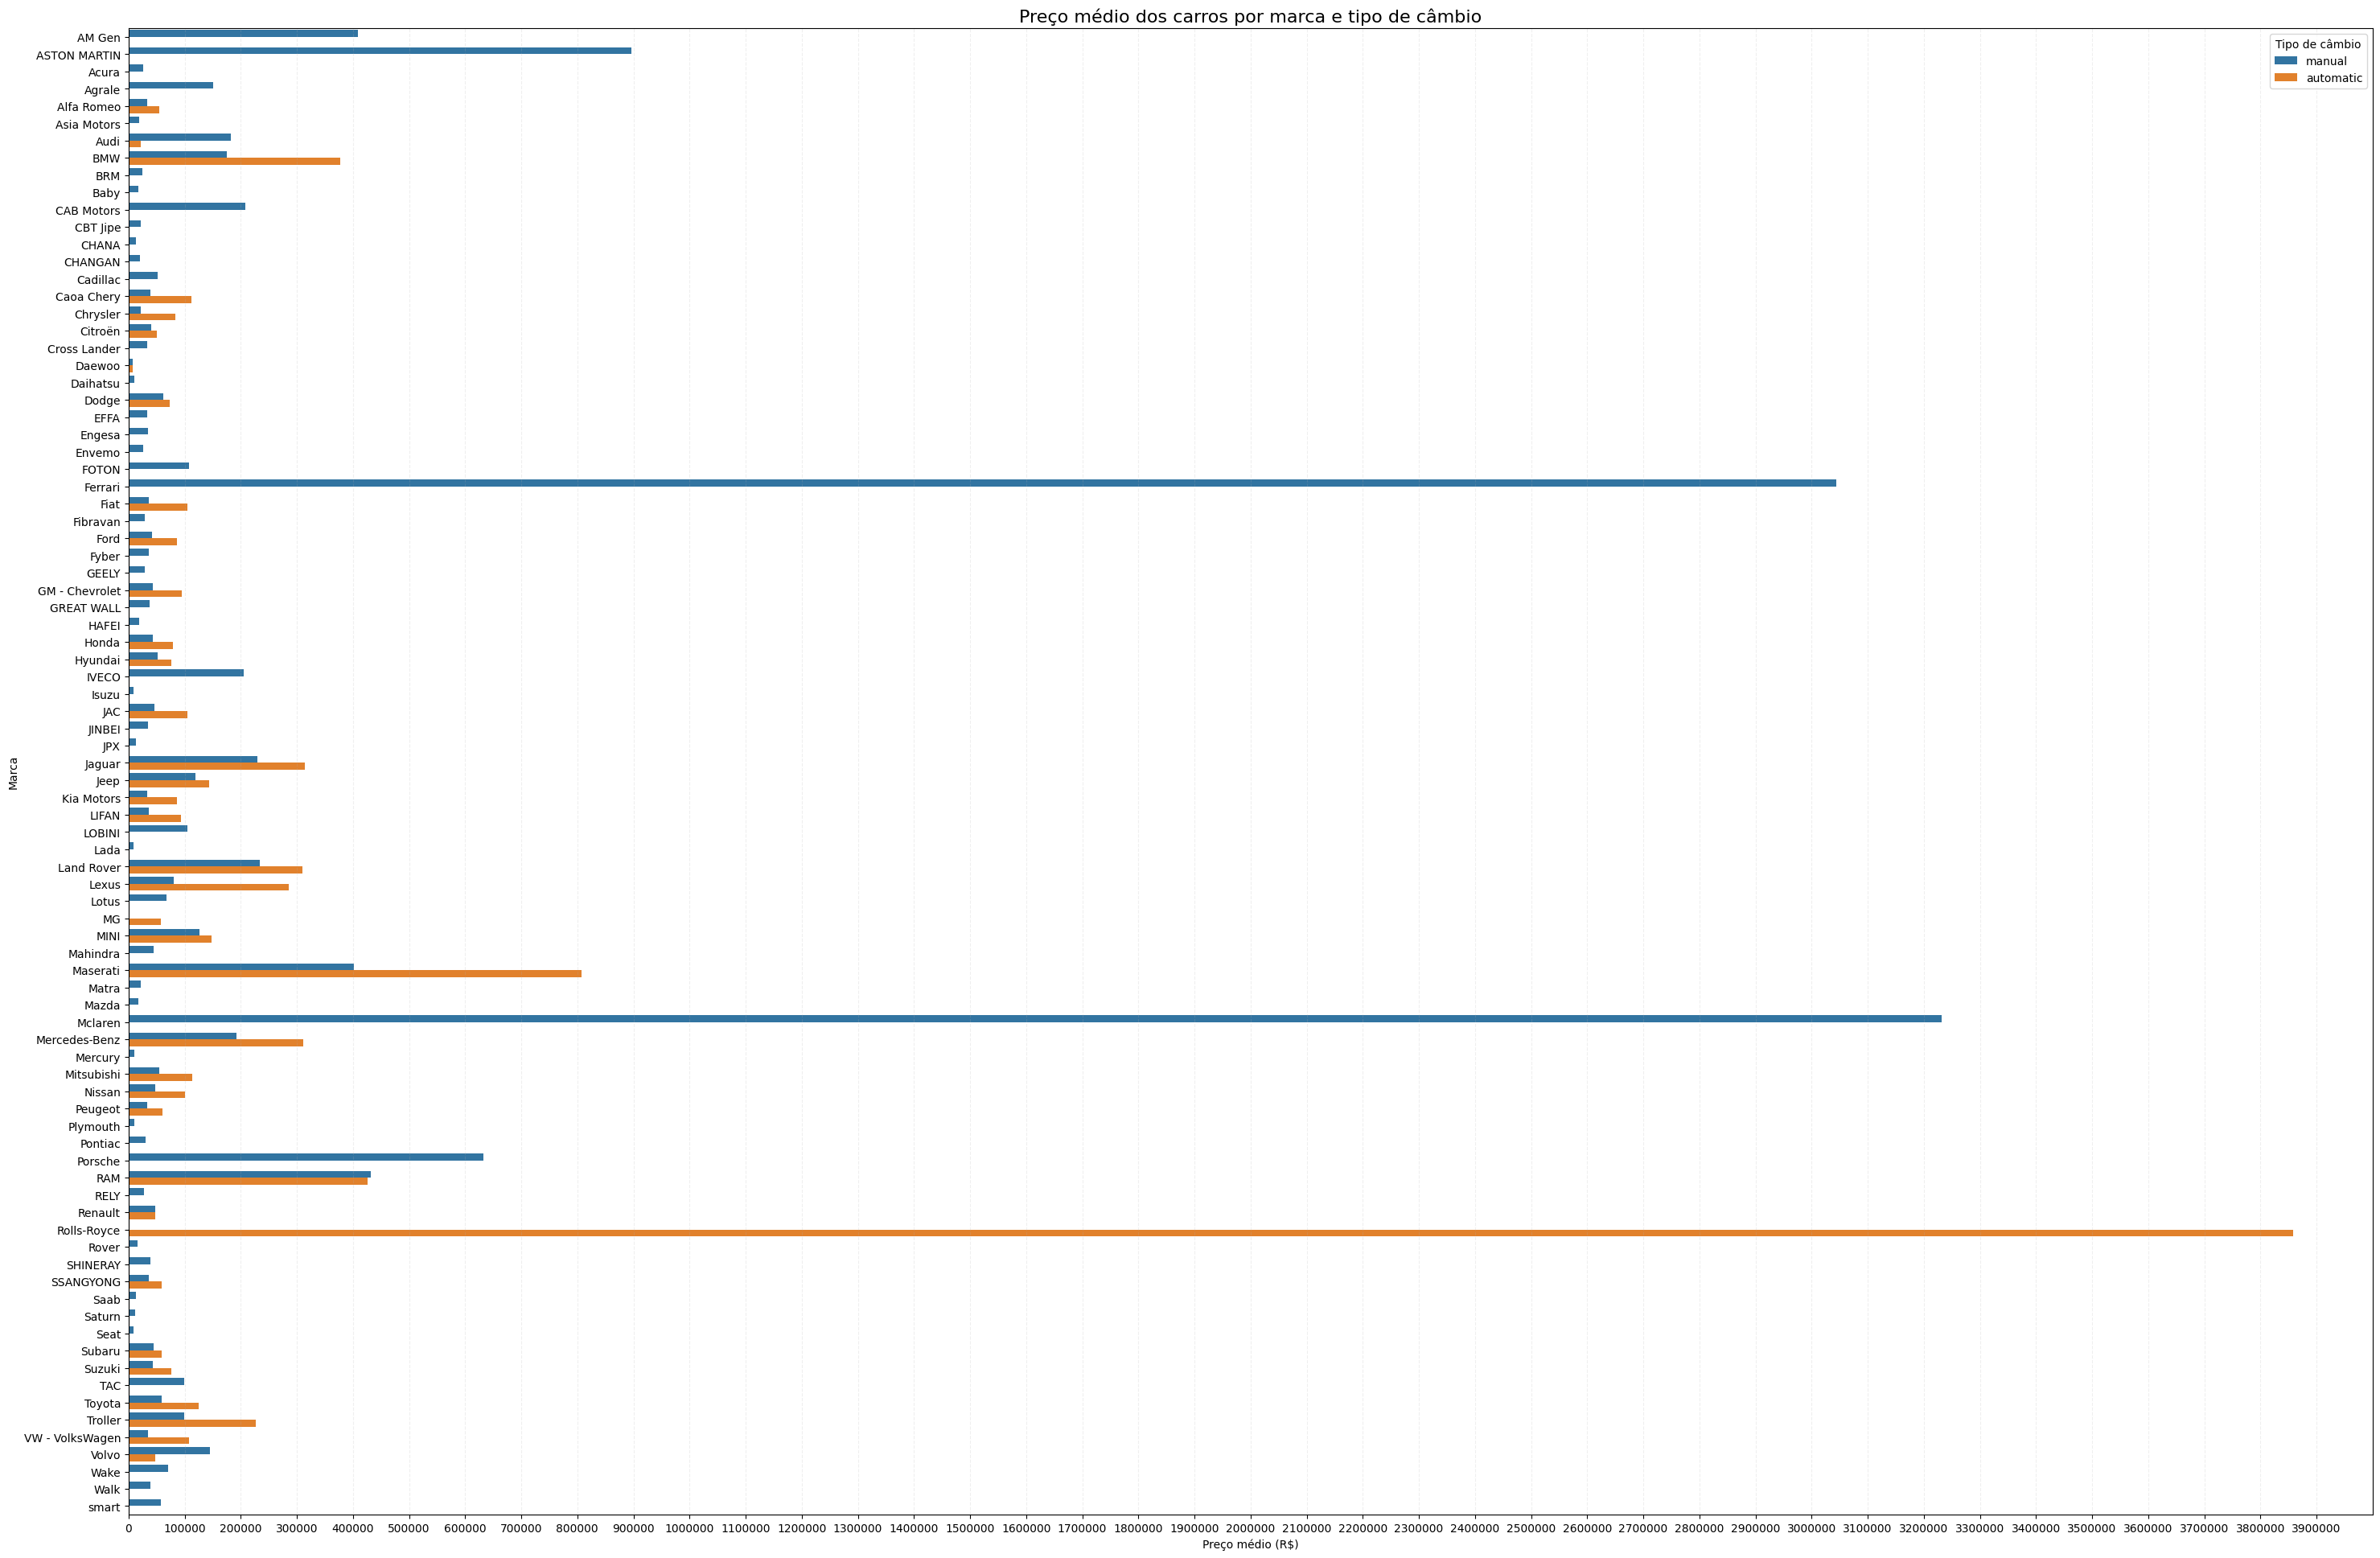

In [67]:
import numpy as np

plt.figure(figsize=(36,24))

media = df.groupby(['brand','gear'])['avg_price_brl'].mean().reset_index()

sns.barplot(data=media, y='brand', x='avg_price_brl', hue='gear')

plt.title("Preço médio dos carros por marca e tipo de câmbio", fontsize=16)
plt.xlabel("Preço médio (R$)")
plt.ylabel("Marca")

plt.legend(title="Tipo de câmbio")

plt.xlim(0, 4000000)

plt.xticks(np.arange(0, 4000000, 100000))

plt.grid(axis='x', linestyle='--', alpha=0.2)

plt.ticklabel_format(style='plain', axis='x')

plt.show()

**2.e Explicação**

O gráfico apresenta o preço médio dos veículos considerando a marca e o tipo de câmbio (engrenagem componte interno do cambio- porém está conforme a planilha que só aparece automático e manual). Observa-se que veículos com câmbio automático tendem a possuir preços médios mais elevados em diversas marcas. Isso ocorre porque o câmbio automático geralmente está presente em versões mais modernas ou mais equipadas dos veículos.

**2.f Preço médio por marca e combustível**

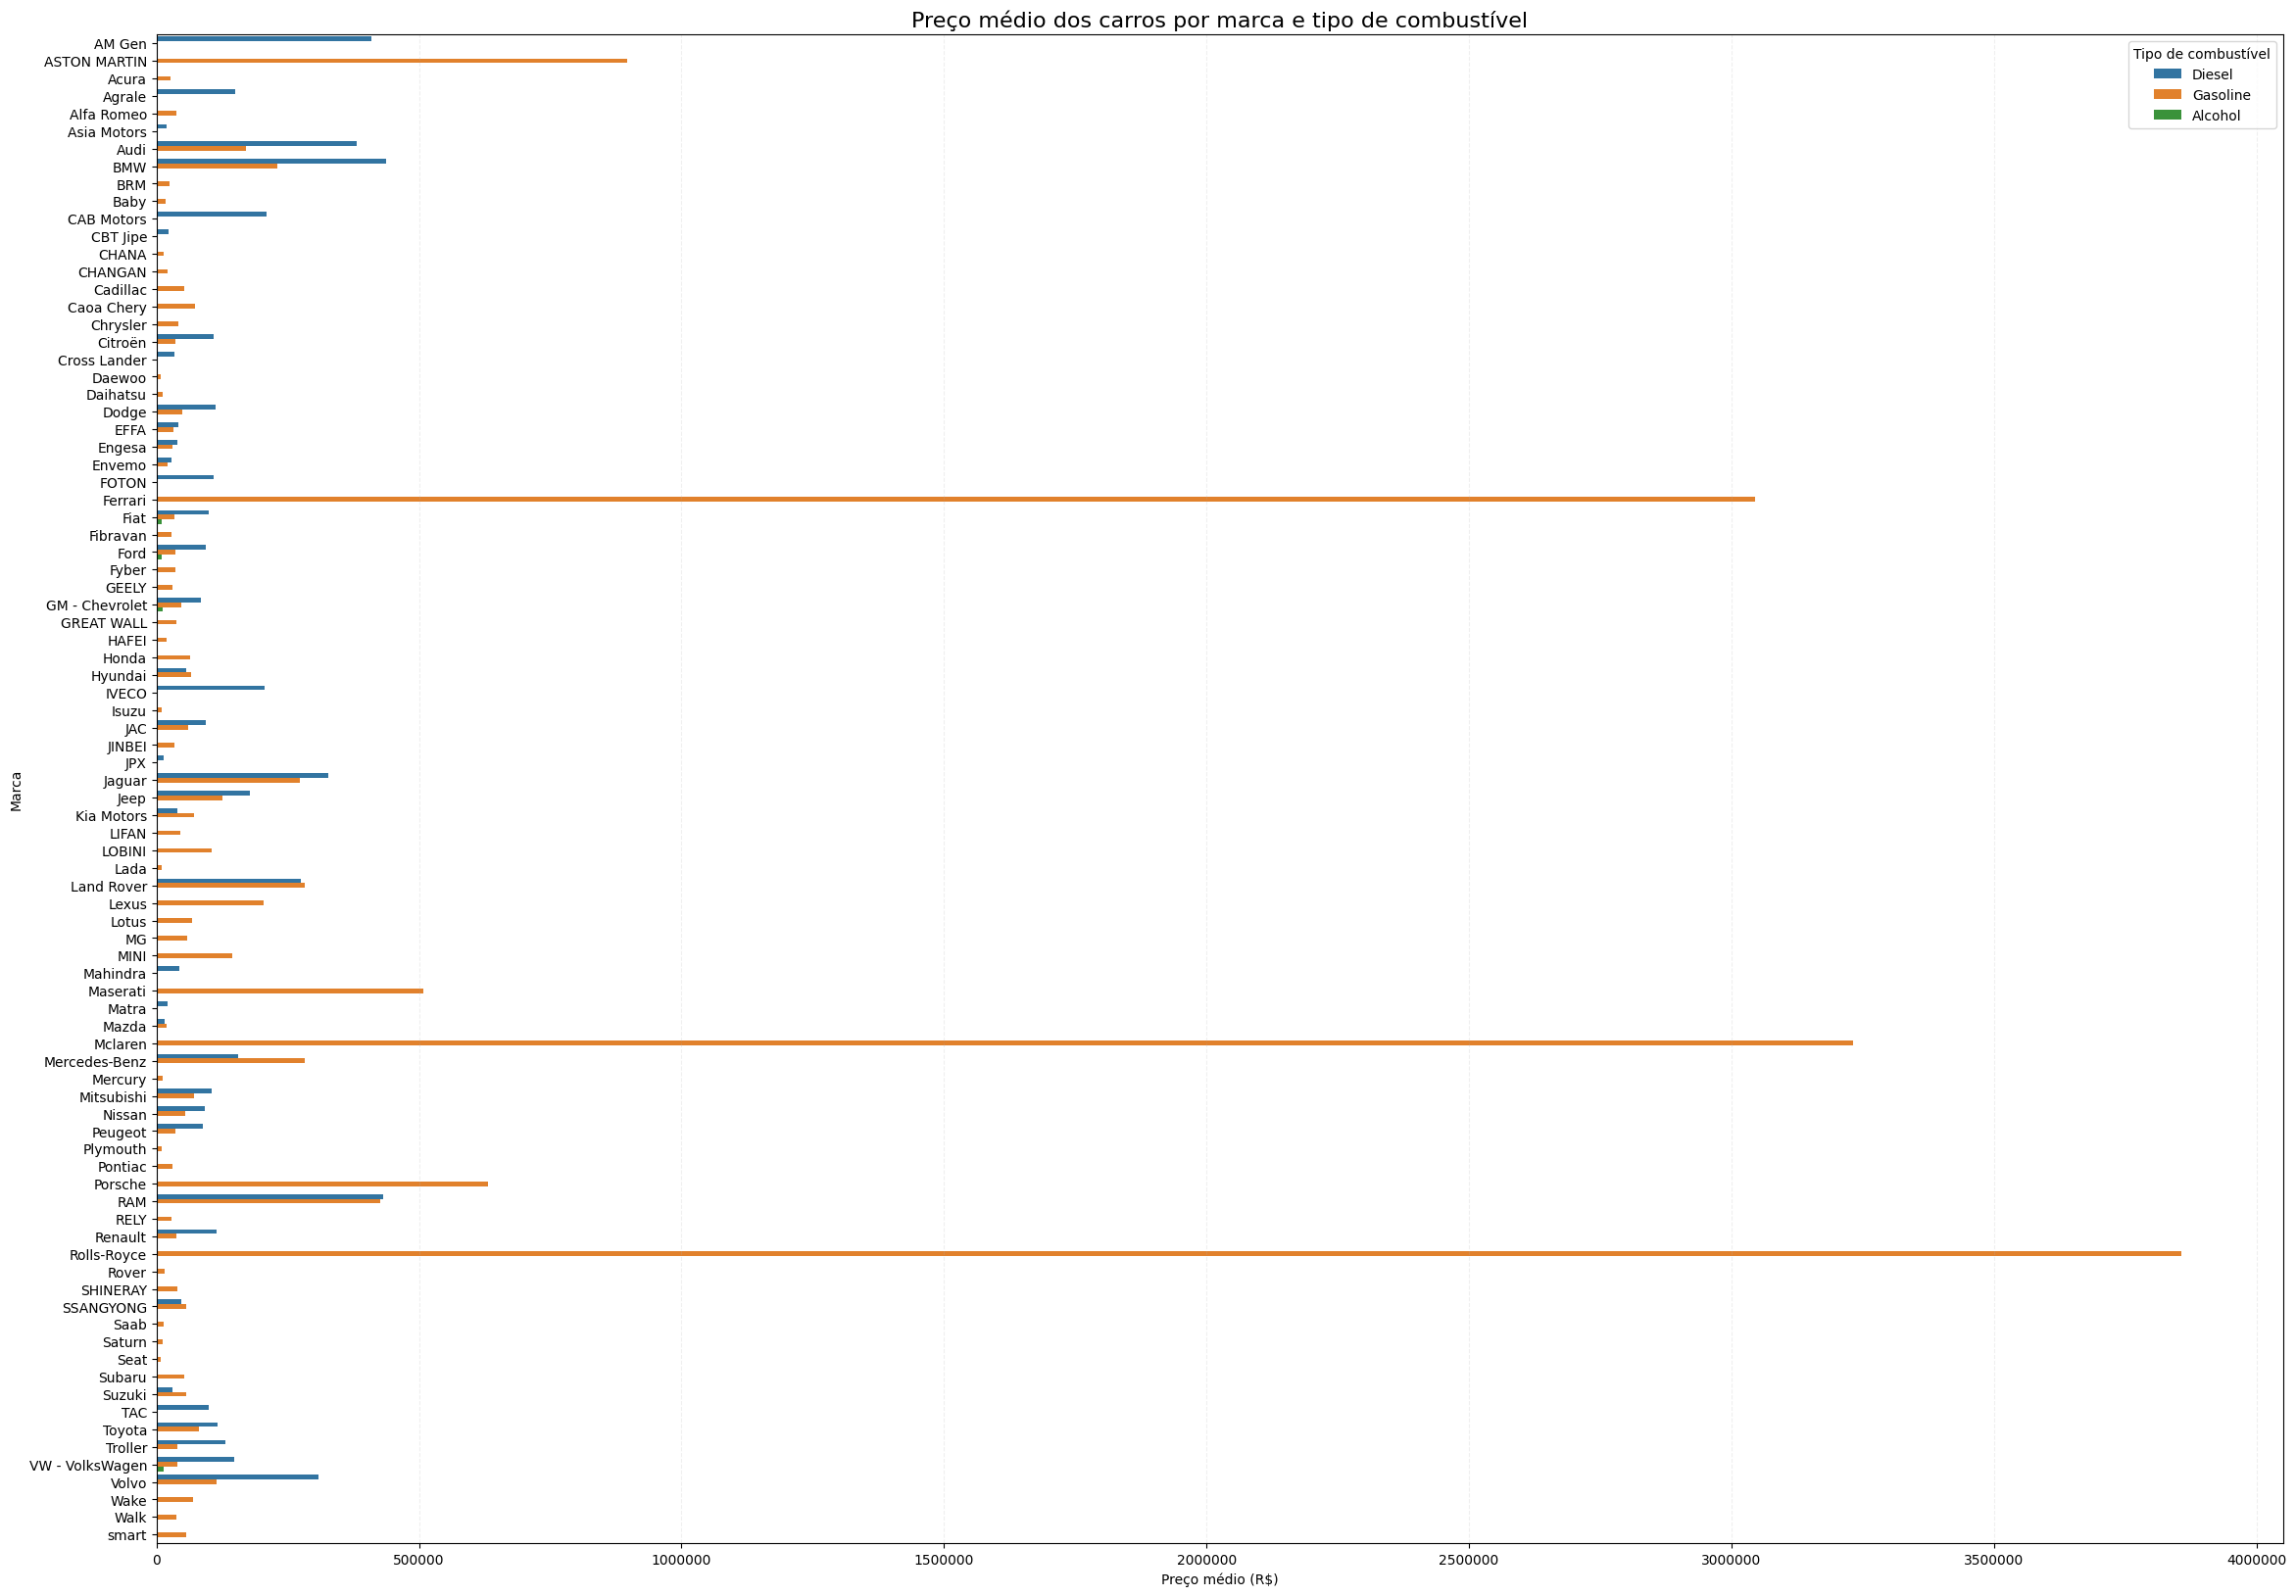

In [93]:
import numpy as np

plt.figure(figsize=(28,20))

# média por marca e combustível
media = df.groupby(['brand','fuel'])['avg_price_brl'].mean().reset_index()

sns.barplot(data=media, y='brand', x='avg_price_brl', hue='fuel')

plt.title("Preço médio dos carros por marca e tipo de combustível", fontsize=16)
plt.xlabel("Preço médio (R$)")
plt.ylabel("Marca")

plt.legend(title="Tipo de combustível")

plt.grid(axis='x', linestyle='--', alpha=0.2)

plt.ticklabel_format(style='plain', axis='x')

plt.show()

**2.g Explicação**

O gráfico apresenta o preço médio dos veículos considerando a marca e o tipo de combustível. Nota-se que veículos movidos a diesel frequentemente apresentam preços médios mais elevados, pois esse tipo de combustível é mais comum em caminhonetes e veículos utilitários, que possuem maior valor de mercado. Já veículos movidos a gasolina apresentam maior variedade de preços entre as marca